# Car Price Prediction project

At this stage, we're trying to perform a data sanity check on the *whole raw dataset*.

## Environment setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Minimal raw data inspection

In [2]:
data = pd.read_csv("./data/car_price_prediction.csv")
data.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [3]:
data.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

## Inspected schema (intuition)

The above summary indicates that there are 5 numeric fields, with a single float64 item. However,
after a quick glance at the first rows, it seems like more careful inspection may be required.

Let's prepare a quick data card first :

**Features**
- ID : Record ID, numerical
- Levy : ??? (must consult Kaggle data card), numerical (possible missing data)
- Manufacturer : Car manufacturer, categorical (nominal)
- Model : Car model, categorical (nominal)
- Prod. Year : Car production year, numerical
- Category : Car category, categorical (nominal)
- Leather interior : categorical (possibly binary)
- Fuel type : categorical (nominal)
- Engine volume : Volume of car engine (most probably : cubic centimeters or CC, scaled down by 1000), numerical (possible malformed data)
- Mileage : Total kilometers driven by the car, numerical, needs transform (possible missing data)
- Cylinders : Number of cylinders, numerical
- Gear box type : categorical (nominal)
- Drive wheels : categorical (nominal)
- Doors : Number of doors, probably numerical (possible malformed data or needs transform)
- Wheel : categorical (nominal)
- Color : Car color categorical (nominal)
- Airbags : Number of airbags, numerical

**Target**
- Price : Car price (most probably : USD, no scaling down), numerical

## Missing data inspection

Let's inspect the following features more closely, looking for missing/invalid values :
- Levy
- Engine volume
- Mileage
- Doors

In [5]:
# Utility function to inspect (i.e., check and report) feature values
def inspect_values(data, col, conv_func):
    val_counts = data[col].value_counts()
    missing_vals = []
    for val in val_counts.index:
        try:
            num = conv_func(val)
        except:
            missing_vals.append(val)
    
    print(f"{len(val_counts)} unique values in '{col}'\n")
    print(f"{len(missing_vals)} Invalid/Missing value(s) in '{col}':\n{missing_vals}")

In [6]:
inspect_values(data, "Levy", int)

559 unique values in 'Levy'

1 Invalid/Missing value(s) in 'Levy':
['-']


In [7]:
val_counts = data["Doors"].value_counts()
val_counts

Doors
04-May    18332
02-Mar      777
>5          128
Name: count, dtype: int64

In [8]:
inspect_values(data, "Engine volume", float)

107 unique values in 'Engine volume'

42 Invalid/Missing value(s) in 'Engine volume':
['2.0 Turbo', '3.0 Turbo', '2.2 Turbo', '1.8 Turbo', '1.4 Turbo', '1.6 Turbo', '2.5 Turbo', '1.5 Turbo', '2.4 Turbo', '2.7 Turbo', '3.5 Turbo', '1.7 Turbo', '1.9 Turbo', '4.4 Turbo', '3.2 Turbo', '1.3 Turbo', '4.7 Turbo', '2.3 Turbo', '2.8 Turbo', '2.9 Turbo', '5.5 Turbo', '1.0 Turbo', '4.5 Turbo', '0.7 Turbo', '3.6 Turbo', '4.6 Turbo', '1.2 Turbo', '5.0 Turbo', '2.1 Turbo', '6.3 Turbo', '4.0 Turbo', '0.6 Turbo', '4.8 Turbo', '3.7 Turbo', '4.2 Turbo', '0.2 Turbo', '0.8 Turbo', '5.7 Turbo', '0.4 Turbo', '5.4 Turbo', '0.3 Turbo', '1.1 Turbo']


In [9]:
val_counts = data["Mileage"].value_counts()
missing_vals = []
for val in val_counts.index:
    try:
        num = float(val.removesuffix(" km"))
    except:
        missing_vals.append(val)

print(f"{len(val_counts)} unique values in 'Mileage'\n")
print(f"{len(missing_vals)} Invalid/Missing value(s) in 'Mileage':\n{missing_vals}")

7687 unique values in 'Mileage'

0 Invalid/Missing value(s) in 'Mileage':
[]


Let's inspect other categorical features to make sure there's no missing value indicators

In [10]:
# Quick inspection of unique values in categorical features
cat_cols = [
    "Category", "Leather interior", "Fuel type", "Gear box type",
    "Drive wheels", "Wheel", "Color"
]

uni_vals = []
for col in cat_cols:
    val_counts = data[col].value_counts()
    print(f"\n{len(val_counts)} Unique values in '{col}'")
    print(list(val_counts.index))


11 Unique values in 'Category'
['Sedan', 'Jeep', 'Hatchback', 'Minivan', 'Coupe', 'Universal', 'Microbus', 'Goods wagon', 'Pickup', 'Cabriolet', 'Limousine']

2 Unique values in 'Leather interior'
['Yes', 'No']

7 Unique values in 'Fuel type'
['Petrol', 'Diesel', 'Hybrid', 'LPG', 'CNG', 'Plug-in Hybrid', 'Hydrogen']

4 Unique values in 'Gear box type'
['Automatic', 'Tiptronic', 'Manual', 'Variator']

3 Unique values in 'Drive wheels'
['Front', '4x4', 'Rear']

2 Unique values in 'Wheel'
['Left wheel', 'Right-hand drive']

16 Unique values in 'Color'
['Black', 'White', 'Silver', 'Grey', 'Blue', 'Red', 'Green', 'Orange', 'Brown', 'Carnelian red', 'Golden', 'Beige', 'Sky blue', 'Yellow', 'Purple', 'Pink']


## Target distribution

In [11]:
perc_99 = np.percentile(data["Price"], [99])

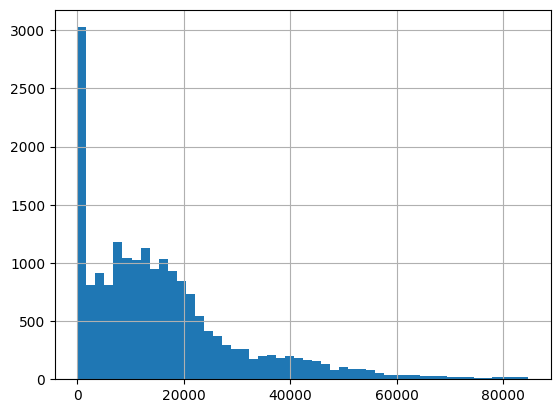

In [12]:
data["Price"].hist(bins=50, range=(0, perc_99[0]))
plt.show()

## Price bins for stratification

In [13]:
# Create price bins at 50th and 90th percentiles
perc_arr = np.percentile(data["Price"], [50, 90])
perc_arr

array([13172., 38609.])

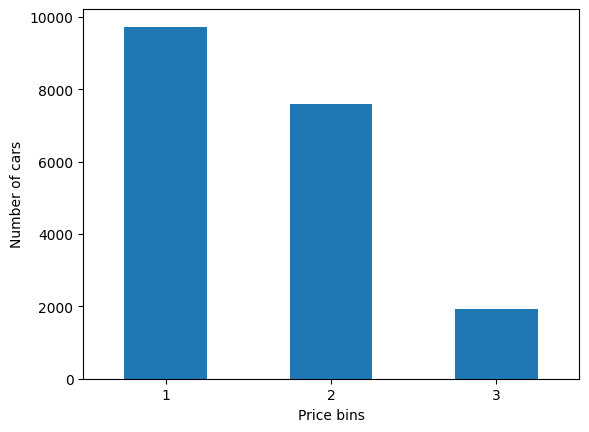

In [14]:
price_bins = pd.cut(data["Price"],
                   bins=[0, perc_arr[0], perc_arr[1], np.inf],
                   labels=[1, 2, 3])
price_bins.value_counts().sort_index().plot.bar(rot=0)
plt.xlabel("Price bins")
plt.ylabel("Number of cars")
plt.show()

## Summary

- Dataset has one ID column (called "ID") which can be safely dropped.
- Target column is "Price" and the unit is (probably) USD.
- Target has a right skewed distribution with extreme outliers.
- To preserve price distribution across splits, stratification will be applied on binned target values.

## Correct stratified splitting

In [15]:
# Temporary code

# Create price bins at 50th and 90th percentiles
perc_arr = np.percentile(data["Price"], [50, 90])
data["Price bin"] = pd.cut(
    data["Price"],
    bins=[0, perc_arr[0], perc_arr[1], np.inf],
    labels=[1, 2, 3]
)
data.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Price bin
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12,2
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8,2
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2,1
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0,1
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4,1


In [18]:
from sklearn.model_selection import train_test_split

rs = 147 # random state
X_train, X_test = train_test_split(data, test_size=0.2, stratify=data["Price bin"], random_state=rs)

print(f"Train shape : {X_train.shape}\nTest shape : {X_test.shape}")

Train shape : (15389, 19)
Test shape : (3848, 19)


In [21]:
X_train["Price bin"].value_counts(normalize=True)

Price bin
1    0.505881
2    0.394178
3    0.099942
Name: proportion, dtype: float64

In [22]:
X_test["Price bin"].value_counts(normalize=True)

Price bin
1    0.505717
2    0.394231
3    0.100052
Name: proportion, dtype: float64